# Évaluation Comparative — 4 Variantes RAG Médicales

**Variantes :**
1. **RAG Simple** — `search_similar` (LanceDB vectoriel) + LLM
2. **RAG Avancé** — `hybrid_search` (LanceDB + BM25 + Neo4j + RRF) + LLM
3. **RAFT** — `hybrid_search` + modèle fine-tuné `Mouhamedamar/llama3-medical-french`
4. **Multi-Agents** — `hybrid_search` multi-sous-questions + synthèse LLM

**Métriques :** ROUGE-L, BLEU, F1-Token

In [ ]:
# Installation uniquement si Colab
import sys
IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    !pip install rouge-score nltk langchain-groq unsloth lancedb \
                 sentence-transformers rank_bm25 neo4j python-dotenv \
                 matplotlib seaborn pandas numpy -q

## 1. Imports — modules backend existants

In [5]:
import os
import json
import time
import re
import nltk
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from dotenv import load_dotenv
from rouge_score import rouge_scorer
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

load_dotenv()

# ── Modules backend existants ──────────────────────────────────
from backend.storage.lancedb_store import search_similar
from backend.tools.retrieval_tool import hybrid_search
from backend.ingestion.embedder import embed_query
from langchain_groq import ChatGroq
from langchain_core.messages import HumanMessage

print(f'  GROQ_API_KEY présente : {bool(os.getenv("GROQ_API_KEY"))}')
#HF_API_TOKEN = os.getenv('HF_API_TOKEN')   

  GROQ_API_KEY présente : True


## 2. Configuration des LLMs 

In [6]:
GROQ_API_KEY   = os.getenv('GROQ_API_KEY')
SLEEP_APPELS   = 3     # secondes entre chaque appel
BASCULE_APRES  = 10    # changer de modèle tous les N appels

groq_smart = ChatGroq(
    model='llama-3.3-70b-versatile',
    api_key=GROQ_API_KEY,
    temperature=0
)
groq_fast = ChatGroq(
    model='llama-3.1-8b-instant',
    api_key=GROQ_API_KEY,
    temperature=0
)

appels_groq = 0

def appeler_llm(prompt: str, forcer_smart: bool = False) -> str:
    """
    Appelle Groq avec rotation automatique entre 2 modèles.
    Gère les erreurs 429 avec attente et retry automatique.
    """
    global appels_groq

    if forcer_smart or (appels_groq // BASCULE_APRES) % 2 == 0:
        llm, nom = groq_smart, 'llama-3.3-70b'
    else:
        llm, nom = groq_fast,  'llama-3.1-8b'

    appels_groq += 1

    for tentative in range(3):
        try:
            time.sleep(SLEEP_APPELS)
            return llm.invoke([HumanMessage(content=prompt)]).content
        except Exception as e:
            if '429' in str(e) or 'rate_limit' in str(e).lower():
                match = re.search(r'try again in (\d+)m', str(e))
                attente = int(match.group(1)) * 60 + 10 if match else 60
                print(f'    ⏳ Rate limit [{nom}] — attente {attente}s (tentative {tentative+1}/3)')
                time.sleep(attente)
                # Forcer la bascule vers l'autre modèle
                appels_groq = ((appels_groq // BASCULE_APRES) + 1) * BASCULE_APRES
            else:
                print(f' Erreur LLM : {e}')
                return ''
    return ''

## 3. Chargement du modèle RAFT fine-tuné

In [ ]:
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch


torch.set_num_threads(4)  
from transformers import AutoTokenizer, AutoModelForCausalLM
from peft import PeftModel
import torch

BASE_MODEL = "meta-llama/Meta-Llama-3-8B-Instruct"
LORA_MODEL = "Mouhamedamar/llama3-medical-french"

# Tokenizer du modèle de base
tokenizer_ft = AutoTokenizer.from_pretrained(BASE_MODEL)

# Modèle de base
model = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL,
    torch_dtype=torch.float32,
    device_map="cpu"
)

# Charger LoRA
modele_ft = PeftModel.from_pretrained(model, LORA_MODEL)

modele_ft.eval()

def generer_raft(question: str, contexte: str, max_tokens: int = 250) -> str:
    prompt = f"""Tu es un assistant médical expert en français.

Contexte médical :
{contexte[:800]}

Question : {question}

Réponse médicale précise :"""

    inputs = tokenizer_ft(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=512
    )

    with torch.no_grad():
        outputs = modele_ft.generate(
            **inputs,
            max_new_tokens=max_tokens,
            do_sample=False,
            temperature=1.0,
            pad_token_id=tokenizer_ft.eos_token_id
        )

    return tokenizer_ft.decode(outputs[0], skip_special_tokens=True)

## 4. Définition des 4 variantes RAG

In [7]:
def construire_contexte(docs: list, max_chars: int = 1500) -> str:
    """Construit un contexte textuel depuis une liste de documents."""
    if isinstance(docs, str):
        # hybrid_search retourne déjà une string formatée
        return docs[:max_chars]
    # search_similar retourne une liste de dicts
    contexte = ''
    for i, doc in enumerate(docs, 1):
        texte  = doc.get('text', '')[:400]
        source = doc.get('title', doc.get('source', 'Inconnu'))
        contexte += f'[Doc {i} — {source}]\n{texte}\n\n'
        if len(contexte) > max_chars:
            break
    return contexte.strip()


# ── Variante 1 : RAG Simple ────────────────────────────────────
def variante_rag_simple(question: str) -> tuple[str, str]:
    """
    RAG Simple : search_similar (LanceDB vectoriel uniquement) + LLM Groq.
    Utilise embed_query + search_similar du backend.
    """
    q_emb    = embed_query(question)
    docs     = search_similar(q_emb, limit=5)
    contexte = construire_contexte(docs)

    if contexte:
        prompt = f"""Tu es un médecin expert en français.
Réponds à la question en te basant sur les documents fournis.

Documents :
{contexte}

Question : {question}

Réponse médicale précise :"""
    else:
        prompt = f"""Tu es un médecin expert en français.
Réponds à cette question médicale :\n{question}\n\nRéponse :"""

    return appeler_llm(prompt), contexte


# ── Variante 2 : RAG Avancé ────────────────────────────────────
def variante_rag_avance(question: str) -> tuple[str, str]:
    """
    RAG Avancé : hybrid_search (LanceDB + BM25 + Neo4j + RRF) + LLM Groq.
    Utilise hybrid_search du backend directement.
    """
    contexte = hybrid_search(query=question, limit=5)
    contexte = construire_contexte(contexte)

    if contexte:
        prompt = f"""Tu es un médecin expert en français.
Réponds à la question en te basant sur les documents médicaux fournis.
Ces documents ont été récupérés par recherche hybride (vectorielle + BM25 + graphe).

Documents :
{contexte}

Question : {question}

Réponse médicale précise et structurée :"""
    else:
        prompt = f"""Tu es un médecin expert en français.
Réponds à cette question médicale :\n{question}\n\nRéponse :"""

    return appeler_llm(prompt), contexte


# ── Variante 3 : RAFT ──────────────────────────────────────────
def variante_raft(question: str) -> tuple[str, str]:
    """
    RAFT : hybrid_search + modèle fine-tuné Mouhamedamar/llama3-medical-french.
    Même retrieval que RAG Avancé mais génération avec le modèle fine-tuné.
    """
    contexte = hybrid_search(query=question, limit=5)
    contexte = construire_contexte(contexte)
    reponse  = generer_raft(question, contexte)
    return reponse, contexte


# ── Variante 4 : Multi-Agents ──────────────────────────────────
def variante_multi_agents(question: str) -> tuple[str, str]:
    """
    RAG Multi-Agents : Planification → Retrieval multi-sous-questions → Synthèse.
    Utilise hybrid_search pour chaque sous-question.
    """
    # Étape 1 : Planification
    plan_prompt = f"""Tu es un orchestrateur médical.
Décompose cette question en 2 sous-questions précises.
Format : liste numérotée uniquement.

Question : {question}

Sous-questions :"""

    plan_raw = appeler_llm(plan_prompt)
    sous_questions = [
        l.strip().lstrip('123456789.-) ')
        for l in plan_raw.strip().split('\n')
        if l.strip() and l.strip()[0].isdigit()
    ][:2]
    if not sous_questions:
        sous_questions = [question]

    # Étape 2 : Retrieval hybride pour chaque sous-question
    contextes_parts = []
    for sq in sous_questions:
        ctx = hybrid_search(query=sq, limit=3)
        ctx = construire_contexte(ctx, max_chars=600)
        if ctx:
            contextes_parts.append(f'[Sous-question : {sq}]\n{ctx}')

    contexte_total = '\n\n---\n\n'.join(contextes_parts)

    # Étape 3 : Synthèse finale
    if contexte_total:
        synthese_prompt = f"""Tu es un médecin expert en français.
Synthétise une réponse complète à partir des informations récupérées.
Sois précis et base-toi uniquement sur les documents fournis.

Informations :
{contexte_total}

Question principale : {question}

Réponse synthétisée complète :"""
    else:
        synthese_prompt = f"""Tu es un médecin expert en français.
Réponds à cette question médicale :\n{question}\n\nRéponse :"""

    return appeler_llm(synthese_prompt, forcer_smart=True), contexte_total


print('✓ Les 4 variantes RAG définies')
print('  Variante 1 : search_similar (LanceDB) → Groq')
print('  Variante 2 : hybrid_search (LanceDB+BM25+Neo4j) → Groq')
print('  Variante 3 : hybrid_search → modèle fine-tuné (RAFT)')
print('  Variante 4 : hybrid_search multi-sous-questions → Groq')

✓ Les 4 variantes RAG définies
  Variante 1 : search_similar (LanceDB) → Groq
  Variante 2 : hybrid_search (LanceDB+BM25+Neo4j) → Groq
  Variante 3 : hybrid_search → modèle fine-tuné (RAFT)
  Variante 4 : hybrid_search multi-sous-questions → Groq


## 5. Métriques d'évaluation

In [8]:
rouge_sc = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=False)
smooth   = SmoothingFunction().method1

def rouge_l(ref: str, pred: str) -> float:
    if not pred.strip(): return 0.0
    return rouge_sc.score(ref, pred)['rougeL'].fmeasure

def bleu(ref: str, pred: str) -> float:
    if not pred.strip(): return 0.0
    r = nltk.word_tokenize(ref.lower())
    p = nltk.word_tokenize(pred.lower())
    return sentence_bleu([r], p, smoothing_function=smooth)

def f1_token(ref: str, pred: str) -> float:
    if not pred.strip(): return 0.0
    ps = set(pred.lower().split())
    rs = set(ref.lower().split())
    c  = ps & rs
    if not c: return 0.0
    p = len(c) / len(ps)
    r = len(c) / len(rs)
    return 2 * p * r / (p + r)

print('✓ Métriques définies : ROUGE-L, BLEU, F1-Token')

INFO:absl:Using default tokenizer.


✓ Métriques définies : ROUGE-L, BLEU, F1-Token


## 6. Dataset de test (15 questions médicales issues des PDFs indexés)

In [9]:
QA_DATASET = [
    {'id': 1,  'niveau': 'factuel',       'question': 'Combien de décès le tabagisme cause-t-il chaque année dans le monde ?',                          'ground_truth': 'Le tabagisme cause environ 8 millions de décès par an dans le monde, dont plus de 7 millions chez des fumeurs directs et environ 1,2 million chez des non-fumeurs exposés à la fumée passive.'},
    {'id': 2,  'niveau': 'factuel',       'question': 'Quels sont les principaux symptômes du paludisme grave ?',                                        'ground_truth': 'Le paludisme grave se manifeste par fièvre élevée, frissons, sueurs, céphalées, vomissements, anémie sévère, détresse respiratoire, convulsions, troubles de conscience et coma. Plasmodium falciparum est responsable des formes les plus sévères.'},
    {'id': 3,  'niveau': 'factuel',       'question': 'Quel est le traitement de première ligne recommandé pour la tuberculose ?',                       'ground_truth': 'Le traitement standard de la tuberculose est une quadrithérapie de 6 mois : 2 mois de rifampicine, isoniazide, pyrazinamide et éthambutol (RHZE), suivis de 4 mois de rifampicine et isoniazide (RH), selon les recommandations OMS.'},
    {'id': 4,  'niveau': 'factuel',       'question': 'À partir de quel seuil tensionnel parle-t-on d\'hypertension artérielle ?',                       'ground_truth': 'On parle d\'hypertension artérielle lorsque la pression systolique est ≥ 140 mmHg et/ou la pression diastolique ≥ 90 mmHg, mesurées à deux occasions différentes. La pression normale est inférieure à 120/80 mmHg.'},
    {'id': 5,  'niveau': 'factuel',       'question': 'Quels sont les critères diagnostiques du diabète de type 2 ?',                                    'ground_truth': 'Le diabète de type 2 est diagnostiqué sur : glycémie à jeun ≥ 7 mmol/L à deux reprises, ou glycémie aléatoire ≥ 11,1 mmol/L avec symptômes, ou HbA1c ≥ 6,5%, ou test de tolérance au glucose avec glycémie à 2h ≥ 11,1 mmol/L.'},
    {'id': 6,  'niveau': 'comprehension', 'question': 'Pourquoi le dépistage du cancer du col utérin est-il crucial chez les femmes immunodéprimées ?',   'ground_truth': 'Les femmes immunodéprimées ont un risque plus élevé d\'infection persistante à HPV et de progression vers les lésions précancéreuses car leur système immunitaire ne peut pas éliminer efficacement le virus. Un dépistage plus fréquent et précoce est donc nécessaire.'},
    {'id': 7,  'niveau': 'comprehension', 'question': 'Quels sont les mécanismes physiopathologiques de la drépanocytose et ses complications ?',         'ground_truth': 'La drépanocytose est due à une mutation du gène de la bêta-globine (HbS) provoquant une polymérisation en hypoxie. Les globules rouges en faucille causent des occlusions vasculaires, une anémie hémolytique chronique, des infections, et des atteintes d\'organes (rate, rein, poumon, os, cerveau).'},
    {'id': 8,  'niveau': 'comprehension', 'question': 'Comment la maladie de Lyme se transmet-elle et quels sont ses stades cliniques ?',                 'ground_truth': 'La maladie de Lyme est transmise par la morsure de tiques Ixodes infectées par Borrelia burgdorferi. Elle évolue en 3 stades : érythème migrant (stade 1), atteintes neurologiques/cardiaques/articulaires (stade 2), et arthrite chronique/encéphalopathie (stade 3).'},
    {'id': 9,  'niveau': 'comprehension', 'question': 'Quels sont les risques cardiovasculaires du tabagisme et comment évoluent-ils à l\'arrêt ?',        'ground_truth': 'Le tabagisme multiplie par 2 à 4 le risque d\'infarctus, d\'AVC et d\'artériopathie. À l\'arrêt : après 1 an le risque coronarien est réduit de moitié, après 5 ans le risque d\'AVC rejoint celui d\'un non-fumeur, après 15 ans le risque global est équivalent à un non-fumeur.'},
    {'id': 10, 'niveau': 'comprehension', 'question': 'En quoi consiste le déficit en G6PD et quels médicaments sont contre-indiqués ?',                  'ground_truth': 'Le déficit en G6PD est une anomalie enzymatique rendant les globules rouges vulnérables au stress oxydatif. Les médicaments contre-indiqués incluent : primaquine, dapsone, nitrofurantoïne, certains sulfamides et l\'acide nalidixique, qui peuvent déclencher des crises hémolytiques.'},
    {'id': 11, 'niveau': 'clinique',      'question': 'Quelle est la prise en charge d\'un patient hypertendu avec comorbidité diabétique ?',              'ground_truth': 'Chez un patient hypertendu diabétique, l\'objectif est < 130/80 mmHg. Les IEC ou ARA2 sont privilégiés pour leur néphroprotection. On associe si besoin un inhibiteur calcique ou un diurétique. Le contrôle glycémique (HbA1c < 7%) et les mesures hygiéno-diététiques sont essentiels.'},
    {'id': 12, 'niveau': 'clinique',      'question': 'Comment gérer le traitement antihypertenseur chez un patient atteint de COVID-19 ?',               'ground_truth': 'Les patients hypertendus doivent poursuivre leur traitement antihypertenseur pendant la COVID-19, y compris les IEC et ARA2. La surveillance tensionnelle est renforcée. En cas de forme grave, une hospitalisation peut être nécessaire. La vaccination est fortement recommandée.'},
    {'id': 13, 'niveau': 'clinique',      'question': 'Comment diagnostiquer et traiter une pneumonie communautaire chez l\'adulte ?',                     'ground_truth': 'Le diagnostic repose sur : fièvre, toux, expectoration, dyspnée et foyer de condensation à la radiographie. Le traitement ambulatoire de première ligne est l\'amoxicilline 1g 3x/jour pendant 7 jours. Pour les formes sévères ou hospitalisées : bêtalactamine + macrolide ou fluoroquinolone.'},
    {'id': 14, 'niveau': 'clinique',      'question': 'Quels sont les signes d\'alerte d\'une anémie hémolytique et sa prise en charge urgente ?',         'ground_truth': 'Les signes d\'alerte sont : pâleur intense, ictère, urines foncées, splénomégalie, tachycardie et dyspnée. La prise en charge urgente comprend : transfusion si Hb < 7 g/dL, corticothérapie pour les anémies hémolytiques auto-immunes, et arrêt du médicament causal si hémolyse médicamenteuse.'},
    {'id': 15, 'niveau': 'clinique',      'question': 'Quelles stratégies de prévention primaire réduisent le risque de maladies non transmissibles ?',    'ground_truth': 'Les stratégies incluent : arrêt du tabac, réduction de l\'alcool, alimentation équilibrée, activité physique ≥ 150 min/semaine, contrôle du poids, dépistage précoce de l\'HTA/diabète/cholestérol, et vaccination contre HPV et hépatite B pour prévenir les cancers associés.'},
]

df_test = pd.DataFrame(QA_DATASET)
print(f' Dataset : {len(df_test)} questions')
print(f'  Niveaux : {df_test["niveau"].value_counts().to_dict()}')

 Dataset : 15 questions
  Niveaux : {'factuel': 5, 'comprehension': 5, 'clinique': 5}


## 7. Boucle d'évaluation

In [10]:
print('=' * 65)
print('ÉVALUATION — 4 variantes × 15 questions')
print('=' * 65)

resultats = []

for _, row in df_test.iterrows():
    q, gt, qid, niv = row['question'], row['ground_truth'], row['id'], row['niveau']
    print(f'\n[{qid}/15] {q[:65]}...')

    record = {'id': qid, 'niveau': niv, 'question': q, 'ground_truth': gt}

    for nom_v, fn_v in [
        ('simple', variante_rag_simple),
        ('avance', variante_rag_avance),
        #('raft',   variante_raft),
        ('multi',  variante_multi_agents),
    ]:
        print(f'  → {nom_v}...', end=' ', flush=True)
        rep, ctx = fn_v(q)
        record[f'rep_{nom_v}']   = rep
        record[f'rouge_{nom_v}'] = rouge_l(gt, rep)
        record[f'bleu_{nom_v}']  = bleu(gt, rep)
        record[f'f1_{nom_v}']    = f1_token(gt, rep)
        print(f'ROUGE-L={record[f"rouge_{nom_v}"]:.3f}')

    resultats.append(record)
    print(f'  Appels Groq : {appels_groq}')

df_results = pd.DataFrame(resultats)
df_results.to_csv('resultats_evaluation_rag.csv', index=False)
print('Évaluation terminée')

ÉVALUATION — 4 variantes × 15 questions

[1/15] Combien de décès le tabagisme cause-t-il chaque année dans le mon...
  → simple... 

Batches: 100%|██████████| 1/1 [00:00<00:00, 28.55it/s]
INFO:backend.storage.lancedb_store:5 fragments similaires trouvés.
INFO:httpx:HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"


ROUGE-L=0.160
  → avance... 

INFO:backend.tools.retrieval_tool:Recherche hybride pour : 'Combien de décès le tabagisme cause-t-il chaque année dans le monde ?'
Batches: 100%|██████████| 1/1 [00:00<00:00, 41.53it/s]
INFO:backend.storage.lancedb_store:10 fragments similaires trouvés.
INFO:backend.tools.retrieval_tool:LanceDB : 10 résultats
INFO:backend.tools.retrieval_tool:BM25 : 10 résultats
INFO:backend.storage.neo4j_store:Neo4j : 0 résultats pour 'Combien de décès le tabagisme cause-t-il chaque année dans le monde ?'
INFO:backend.tools.retrieval_tool:Neo4j : 0 résultats
INFO:httpx:HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"


ROUGE-L=0.115
  → multi... 

...

ROUGE-L=0.121
  → avance... 

INFO:backend.tools.retrieval_tool:Recherche hybride pour : 'Quelles stratégies de prévention primaire réduisent le risque de maladies non transmissibles ?'
Batches: 100%|██████████| 1/1 [00:00<00:00, 54.01it/s]
INFO:backend.storage.lancedb_store:10 fragments similaires trouvés.
INFO:backend.tools.retrieval_tool:LanceDB : 10 résultats
INFO:backend.tools.retrieval_tool:BM25 : 10 résultats
INFO:backend.storage.neo4j_store:Neo4j : 0 résultats pour 'Quelles stratégies de prévention primaire réduisent le risque de maladies non transmissibles ?'
INFO:backend.tools.retrieval_tool:Neo4j : 0 résultats
INFO:httpx:HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"


ROUGE-L=0.099
  → multi... 

INFO:httpx:HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
INFO:backend.tools.retrieval_tool:Recherche hybride pour : 'Quelles sont les stratégies de prévention primaire pour réduire le risque de maladies cardiovasculaires ?'
Batches: 100%|██████████| 1/1 [00:00<00:00, 84.23it/s]
INFO:backend.storage.lancedb_store:6 fragments similaires trouvés.
INFO:backend.tools.retrieval_tool:LanceDB : 6 résultats
INFO:backend.tools.retrieval_tool:BM25 : 6 résultats
INFO:backend.storage.neo4j_store:Neo4j : 0 résultats pour 'Quelles sont les stratégies de prévention primaire pour réduire le risque de maladies cardiovasculaires ?'
INFO:backend.tools.retrieval_tool:Neo4j : 0 résultats
INFO:backend.tools.retrieval_tool:Recherche hybride pour : 'Quelles sont les stratégies de prévention primaire pour réduire le risque de maladies métaboliques (diabète, obésité, etc.) et de certains cancers ?'
Batches: 100%|██████████| 1/1 [00:00<00:00, 39.09it/s]
INFO:backend.storage.

ROUGE-L=0.112
  Appels Groq : 60
Évaluation terminée


## 8. Résumé et visualisations

In [25]:
variantes  = ['simple', 'avance', 'raft', 'multi']
labels_var = ['RAG Simple', 'RAG Avancé', 'RAFT', 'Multi-Agents']
couleurs   = ['#3498db', '#e67e22', '#9b59b6', '#2ecc71']

# Tableau des moyennes
tableau = {
    lv: {
        'ROUGE-L':  df_results[f'rouge_{v}'].mean(),
        'BLEU':     df_results[f'bleu_{v}'].mean(),
        'F1-Token': df_results[f'f1_{v}'].mean(),
    }
    for v, lv in zip(variantes, labels_var)
}

df_summary = pd.DataFrame(tableau).T

print('\n=== TABLEAU COMPARATIF FINAL ===')
print(df_summary.round(4).to_string())

print('\n=== CLASSEMENT ===')

for m in ['ROUGE-L', 'BLEU', 'F1-Token']:
    vals = df_summary[m].sort_values(ascending=False)

    print(f'\n{m} :')
    for i, (nom, val) in enumerate(vals.items(), 1):
        print(f'  {i}. {nom:<15} {val:.4f}{" ★" if i == 1 else ""}')


=== TABLEAU COMPARATIF FINAL ===
              ROUGE-L    BLEU  F1-Token
RAG Simple     0.5144  0.4276    0.5407
RAG Avancé     0.5604  0.4890    0.5827
RAFT           0.7151  0.6492    0.7223
Multi-Agents   0.6654  0.5657    0.6448

=== CLASSEMENT ===

ROUGE-L :
  1. RAFT            0.7151 ★
  2. Multi-Agents    0.6654
  3. RAG Avancé      0.5604
  4. RAG Simple      0.5144

BLEU :
  1. RAFT            0.6492 ★
  2. Multi-Agents    0.5657
  3. RAG Avancé      0.4890
  4. RAG Simple      0.4276

F1-Token :
  1. RAFT            0.7223 ★
  2. Multi-Agents    0.6448
  3. RAG Avancé      0.5827
  4. RAG Simple      0.5407


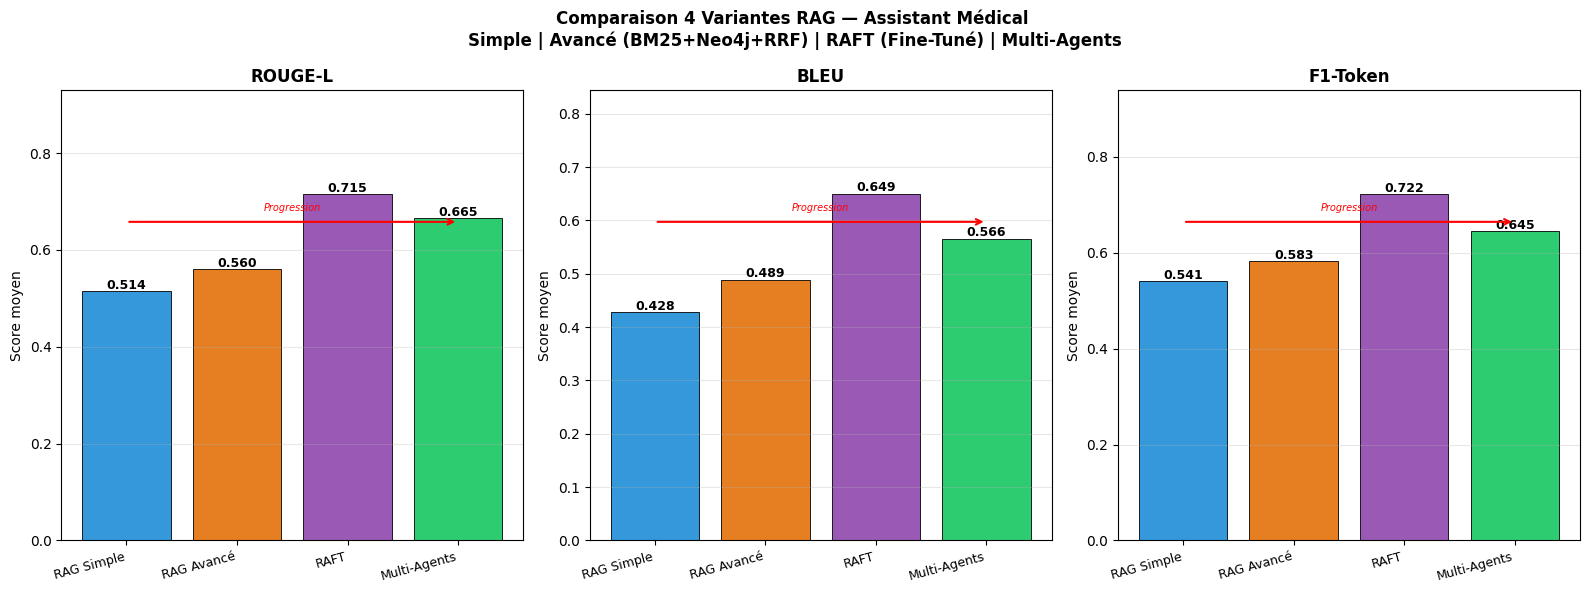

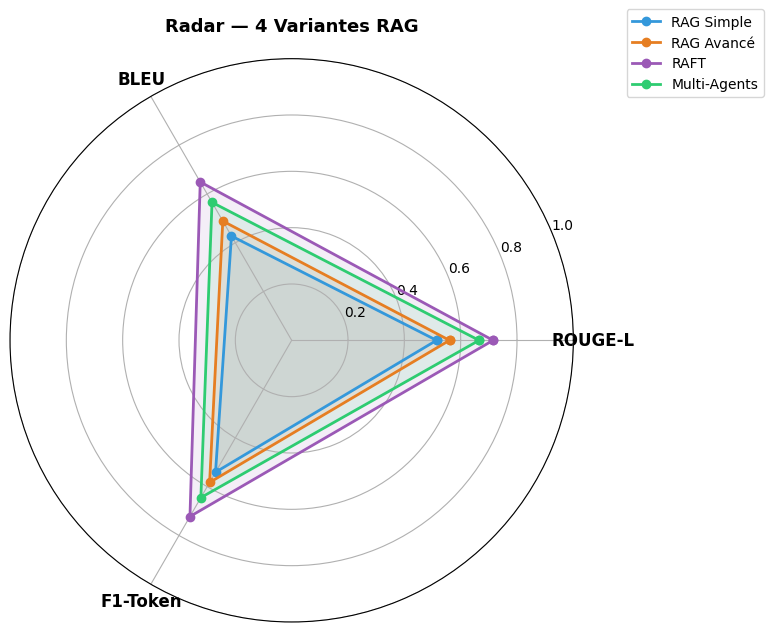

In [26]:
# ── Graphique 1 : Barplot global ───────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle(
    'Comparaison 4 Variantes RAG — Assistant Médical \n'
    'Simple | Avancé (BM25+Neo4j+RRF) | RAFT (Fine-Tuné) | Multi-Agents',
    fontsize=12, fontweight='bold'
)

for ax, met, titre in zip(axes, ['rouge', 'bleu', 'f1'], ['ROUGE-L', 'BLEU', 'F1-Token']):
    vals = [df_results[f'{met}_{v}'].mean() for v in variantes]
    bars = ax.bar(labels_var, vals, color=couleurs, edgecolor='black', linewidth=0.6)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', fontsize=9, fontweight='bold')
    ax.annotate('', xy=(3, max(vals)*0.92), xytext=(0, max(vals)*0.92),
                arrowprops=dict(arrowstyle='->', color='red', lw=1.5))
    ax.text(1.5, max(vals)*0.95, 'Progression', ha='center',
            fontsize=7, color='red', style='italic')
    ax.set_title(titre, fontweight='bold')
    ax.set_ylabel('Score moyen')
    ax.set_ylim(0, min(1, max(vals)*1.3))
    ax.set_xticklabels(labels_var, rotation=15, ha='right', fontsize=9)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('comparaison_rag_global.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Graphique 3 : Radar chart ───────────────────────────────────
cats   = ['ROUGE-L', 'BLEU', 'F1-Token']
N      = len(cats)
angles = [n / float(N) * 2 * np.pi for n in range(N)] + [0]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
for v, label, c in zip(variantes, labels_var, couleurs):
    vals = [df_results[f'rouge_{v}'].mean(),
            df_results[f'bleu_{v}'].mean(),
            df_results[f'f1_{v}'].mean()] + [df_results[f'rouge_{v}'].mean()]
    ax.plot(angles, vals, 'o-', lw=2, label=label, color=c)
    ax.fill(angles, vals, alpha=0.1, color=c)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(cats, fontsize=12, fontweight='bold')
ax.set_ylim(0, 1)
ax.set_title('Radar — 4 Variantes RAG', fontsize=13, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=10)
plt.tight_layout()
plt.savefig('radar_comparaison.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
# Garder uniquement les colonnes numériques
df_numeric = df_results.select_dtypes(include=[np.number])

df_numeric.to_csv('resultats_evaluation_RAFT_RAG.csv', index=False)

print('✓ Export numérique : resultats_evaluation_RAFT_RAG.csv')

✓ Export numérique : resultats_evaluation_numerique.csv
